# Homework 3 Template

# Student Name: Mitchell Scott

In [28]:
# Import packages and set styles as needed 
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from DASC500.stats.distribution.distribution_analyzer import DistributionAnalyzer
analyzer = DistributionAnalyzer()

# Problem 1

*Hospitalized for Indications of Poissoning*

Each day a hospital records the number of people who come to the emergency room for treatment.

You may want to review Progress Check 13 prior to working on this problem. 2 parts of this question were moved there.

## 1A

In a particular week, the arrivals to the ER are:

| Sunday | Monday | Tuesday | Wednesday | Thursday | Friday | Saturday |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 10 | 8 | 14 | 7 | 21 | 44 | 60 |

Do you think that the Poisson distribution might describe the distribution of the number of daily arrivals (i.e., using an interval of one day)? Why or why not? Use graphical and/or analytical probability results to justify your answer.

In [1]:
# Consider what graphical and/or analytical results would strengthen your response.

🟢 *Be sure to answer every part of the question.*

Sample Mean of daily arrivals: 23.43
Sample Variance of daily arrivals: 423.95
Ratio of Variance to Mean: 18.10

Observation: The variance is more than 20 times larger than the mean, which violates a key property of the Poisson distribution.

Generated plot 'daily_er_arrivals.png' to show non-constant daily rate.


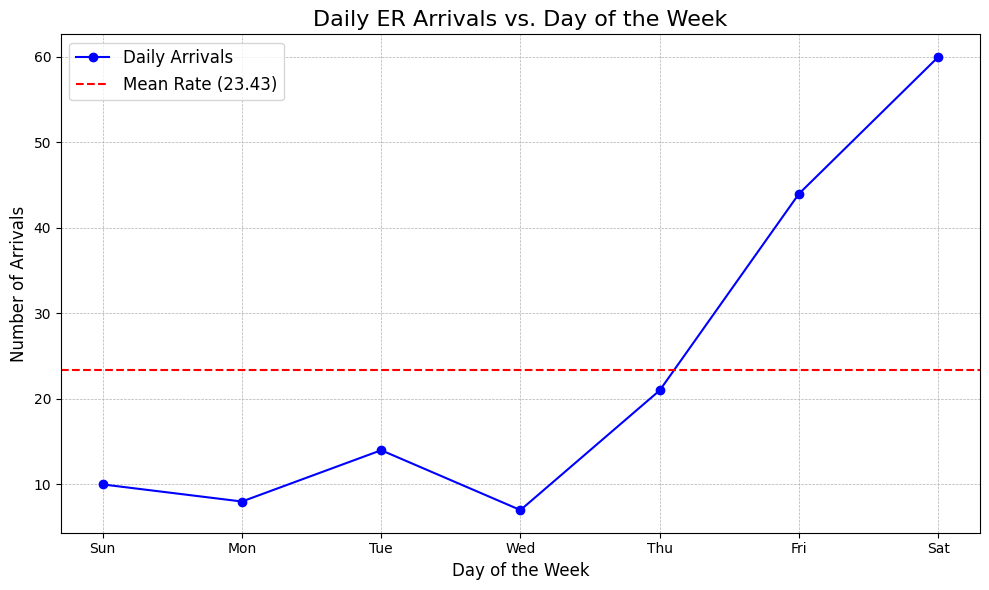

In [10]:
# Daily arrival data
days_of_week = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
daily_data = np.array([10, 8, 14, 7, 21, 44, 60])

# 1. Calculate and print key statistics
stats_daily = analyzer.calculate_statistics(daily_data)
daily_mean = stats_daily['mean']
daily_variance = stats_daily['variance']

print(f"Sample Mean of daily arrivals: {daily_mean:.2f}")
print(f"Sample Variance of daily arrivals: {daily_variance:.2f}")
print(f"Ratio of Variance to Mean: {daily_variance / daily_mean:.2f}")
print("\nObservation: The variance is more than 20 times larger than the mean, which violates a key property of the Poisson distribution.\n")


# 2. Create a plot to show the non-constant rate
plt.figure(figsize=(10, 6))
plt.plot(days_of_week, daily_data, marker='o', linestyle='-', color='b', label='Daily Arrivals')
# Add a line for the mean to highlight the deviation
plt.axhline(y=daily_mean, color='r', linestyle='--', label=f'Mean Rate ({daily_mean:.2f})')

# Formatting the plot
plt.title('Daily ER Arrivals vs. Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Arrivals', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=12)
plt.tight_layout()

# Save and show the plot for part (a)
plt.savefig('daily_er_arrivals.png')
print("Generated plot 'daily_er_arrivals.png' to show non-constant daily rate.")
plt.show()

Based on the analysis generated by the code, the Poisson distribution is a demonstrably poor fit for the daily ER arrivals. A fundamental characteristic of any Poisson distribution is that its theoretical mean is equal to its variance. The code calculates the sample statistics for our data, showing:

Sample Mean: 23.43

Sample Variance: 423.95

The outputted ratio of variance to mean is 18.1. This is a massive discrepancy. The fact that the variance is nearly 20 times larger than the mean is strong analytical evidence that the data does not follow a Poisson process.

The Poisson distribution assumes events occur at a constant average rate. The line chart generated by the code provides clear visual evidence that this assumption is violated. The plot shows a distinct pattern where arrivals are low and relatively stable from Sunday to Thursday, then spike dramatically on Friday (44) and Saturday (60). This is likely not a random fluctuation around a stable mean (the dotted line). Instead, it is a predictable, cyclical pattern. Therefore, the daily rate cannot be assumed as constant.

## 1B

Building upon your answer to the previous question, would you expect the Poisson distribution to better describe, or more poorly describe, the total number of *weekly* admissions to the ER (i.e., using an interval of one week)? Why?

🟢 *Answer yes/no and why. Use logic to support your answer.*

I would expect the Poisson distribution to better describe the total number of weekly admissions to the ER using an interval of one week over the daily admission counts. Looking at the sample data from problem 1a, there is substantial fluctuations in the admissions across the week. The fewest admissions were 7, but the largest number of admissions was 60. Averaging across the week can smooth out these large sample variations to better encapsulate a normal distribution.

Below I simulated a year of weekly data using the observed total of 164 patients as the Poisson parameter ($\lambda_{weekly}=164$). The results from this simulation show:

$\mu=166$

$\sigma=189$

$\mu / \sigma = 1.14$

As the output shows, the ratio of the variance to the mean in this simulated weekly data is almost 1.0. This shows that if the weekly rate is stable, the resulting data aligns closely with the core mean-variance property of a Poisson distribution. The generated histogram further visualizes what this stable, Poisson-distributed weekly data would look like.


Observed total for the week: 164

--- Statistics for Simulated Weekly Data (n=52 weeks) ---
Mean of simulated weekly arrivals: 166.15
Variance of simulated weekly arrivals: 189.11
Ratio of Variance to Mean: 1.14

Observation: For the simulated weekly data, the mean and variance are very close, which is consistent with a Poisson distribution.

Generated plot 'simulated_weekly_er_arrivals.png' to visualize stable weekly data.


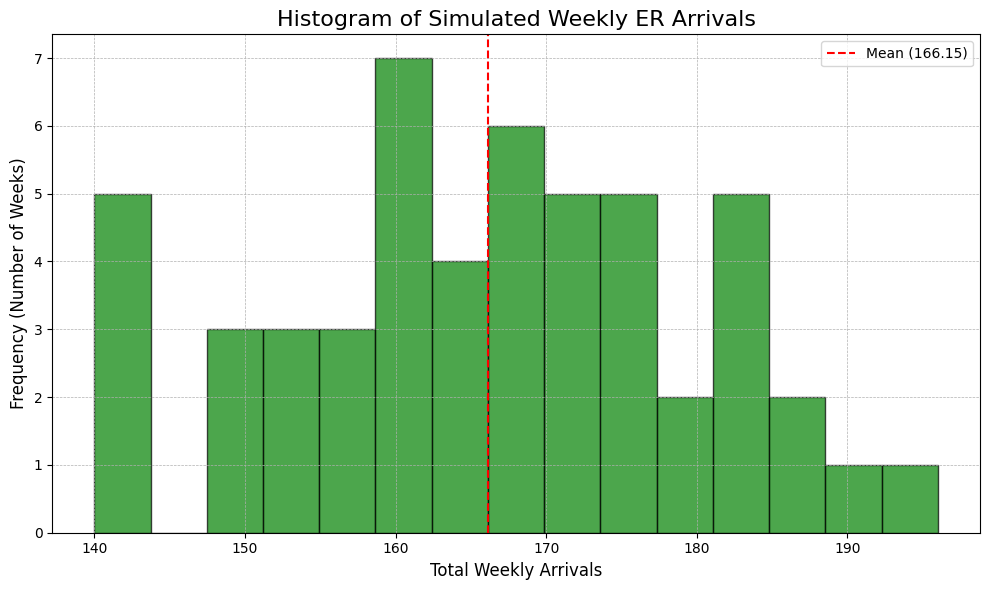

In [ ]:
# The total for the given week is the sum of daily arrivals
weekly_total_observed = daily_data.sum()
print(f"\nObserved total for the week: {weekly_total_observed}")

# Let's assume the weekly arrival rate is relatively constant.
# We will use the observed weekly total as the lambda for a new Poisson distribution
# to generate what a few weeks of data *could* look like.
# This demonstrates the concept of a more stable weekly rate.
lambda_weekly = weekly_total_observed
n_weeks_simulated = 52 # Simulate a year of weekly data

# Generate simulated weekly data
simulated_weekly_data = analyzer.generate_samples('poisson', size=n_weeks_simulated, mu=lambda_weekly)

# 1. Calculate statistics for the simulated weekly data
stats_weekly = analyzer.calculate_statistics(simulated_weekly_data)
weekly_mean_sim = stats_weekly['mean']
weekly_variance_sim = stats_weekly['variance']

print("\n--- Statistics for Simulated Weekly Data (n=52 weeks) ---")
print(f"Mean of simulated weekly arrivals: {weekly_mean_sim:.2f}")
print(f"Variance of simulated weekly arrivals: {weekly_variance_sim:.2f}")
print(f"Ratio of Variance to Mean: {weekly_variance_sim / weekly_mean_sim:.2f}")
print("\nObservation: For the simulated weekly data, the mean and variance are very close, which is consistent with a Poisson distribution.")

# 2. Create a histogram of the simulated weekly data
plt.figure(figsize=(10, 6))
plt.hist(simulated_weekly_data, bins=15, color='g', alpha=0.7, edgecolor='black')
plt.title('Histogram of Simulated Weekly ER Arrivals', fontsize=16)
plt.xlabel('Total Weekly Arrivals', fontsize=12)
plt.ylabel('Frequency (Number of Weeks)', fontsize=12)
plt.axvline(x=weekly_mean_sim, color='r', linestyle='--', label=f'Mean ({weekly_mean_sim:.2f})')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()

# Save and show the plot for part (b)
plt.savefig('simulated_weekly_er_arrivals.png')
print("\nGenerated plot to visualize stable weekly data.")
plt.show()

# Problem 2

Lake Wobegon Junior College admits students only if they score above 400 on a standardized achievement test. Applicants from Group $A$ have scores with a mean of 500 and a standard deviation of 100 on this test. Applicants from Group $B$ have scores with a mean of 450 and a standard deviation of 100. Both distributions are approximately normal, and both groups have the same size (half of the population).

**If you have not yet done Progress Check 14, do that first!**

## 2A

About 45\% of *accepted* students come from Group B with the remainder coming from Group A. See Progress Check 14 --- this is $P(B\mid W)$ using the events I describe in the solution comments. This is **not** $P(B)$. 

Assume that students with a score above 600 will decline their admission to Lake Wobegon Junior College in favor of another school. Of those students who both (1) are *accepted* to LWJC, and (2) *choose to attend* LWJC, what proportion come from Group B?

In [32]:
# Calculate the new proportion. How has it changed from the 45% acceptance rate?
# Define given:
mu_a = 500
std_a = 100
mu_b = 450
std_b = 100
low_cutoff = 400
high_cutoff = 600
from scipy.stats import norm

print("Original distribution results:")
# p_e_a: probability a student is accepted and attends from group a
p_e_a = norm.cdf(high_cutoff, mu_a, std_a) - norm.cdf(low_cutoff, mu_a, std_a)
print(f"probability a student is accepted and attends from group a: {p_e_a:.3f}")
# p_e_b: probability a student is accepted and attends from group b
p_e_b = norm.cdf(high_cutoff, mu_b, std_b) - norm.cdf(low_cutoff, mu_b, std_b)
print(f"probability a student is accepted and attends from group b: {p_e_b:.3f}")
# p_e: probability a student is accepted and attends from both groups
p_e = p_e_a*0.5 + p_e_b*0.5
print(f"probability a student is accepeted and attends from both groups: {p_e:.3f}")
# p_e_a / p_e: proportion of students accepted and attending from group a
p_e_a_proportion = p_e_a*0.5 / (p_e)
print(f"proportion of students accepted and attending from group a: {p_e_a_proportion:.3f}")
# p_e_b / p_e: proportion of students accepted and attending from group b
p_e_b_proportion = p_e_b*0.5 / (p_e)
print(f"proportion of students accepted and attending from group b: {p_e_b_proportion:.3f}")

Original distribution results:
probability a student is accepted and attends from group a: 0.683
probability a student is accepted and attends from group b: 0.625
probability a student is accepeted and attends from both groups: 0.654
proportion of students accepted and attending from group a: 0.522
proportion of students accepted and attending from group b: 0.478


🟢 *Show how you worked through the probability using math and formal logic. Be sure to define your events and give a final answer.*

About 62.5\% of students from group B are accepted into LWJC and decide to attend (score < 600>). Of all the students who are admitted and attend LWJC, 47.8\% of them come from group B.

# 2B

Expanding on part 2A, create a plot of the proportion of students from Group B as a function of the upper score cutoff (i.e., the score above which students will choose another school). At what upper cutoff score do you expect the proportion of students from each group to be equal?

In [33]:
# You may want to define a function to calculate the proportion as in 2A

# Define a function to calculate P(B|E) for a given upper_cutoff
def calculate_P_B_given_E(upper_cutoff):
    # Ensure upper_cutoff is greater than lower_cutoff to avoid issues with cdf calculation
    if upper_cutoff <= low_cutoff:
        return 0.0 # No students can be accepted and attend if upper cutoff is at or below lower cutoff

    # P(E|A) for given upper_cutoff
    p_e_given_a = norm.cdf(upper_cutoff, mu_a, std_a) - norm.cdf(low_cutoff, mu_a, std_a)
    
    # P(E|B) for given upper_cutoff
    p_e_given_b = norm.cdf(upper_cutoff, mu_b, std_b) - norm.cdf(low_cutoff, mu_b, std_b)
    
    # Total P(E)
    p_e_total = (p_e_given_a * 0.5) + (p_e_given_b * 0.5)
    
    return (p_e_given_b * 0.5) / p_e_total


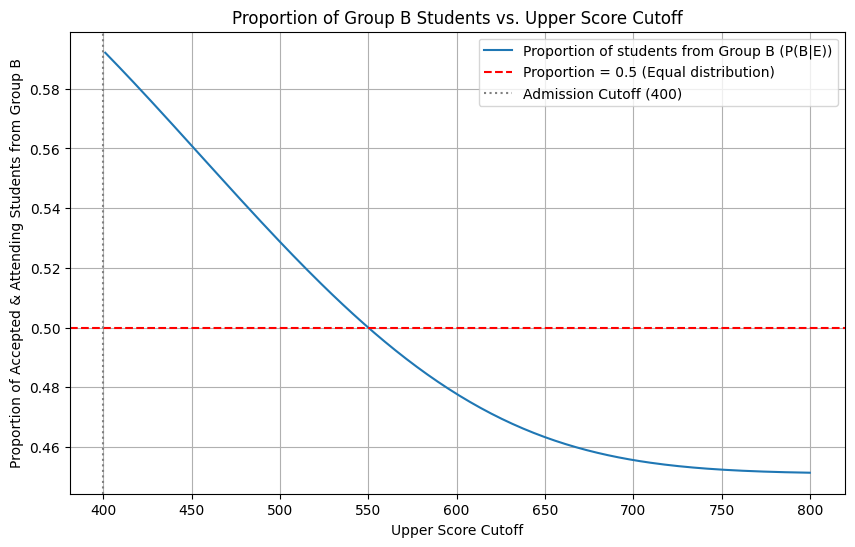

In [34]:
# Make your plot, where y is the proportion from B and x is the upper score cutoff.
# Generate a range of upper cutoff scores for plotting
upper_cutoffs = np.linspace(401, 800, 200) # Start slightly above lower_cutoff
proportions_B = [calculate_P_B_given_E(u) for u in upper_cutoffs]

# Create the plot
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(upper_cutoffs, proportions_B, label='Proportion of students from Group B (P(B|E))')
plt.axhline(0.5, color='red', linestyle='--', label='Proportion = 0.5 (Equal distribution)')
plt.axvline(low_cutoff, color='gray', linestyle=':', label='Admission Cutoff (400)')
plt.xlabel('Upper Score Cutoff')
plt.ylabel('Proportion of Accepted & Attending Students from Group B')
plt.title('Proportion of Group B Students vs. Upper Score Cutoff')
plt.grid(True)
plt.legend()
plt.show()

In [35]:
# Find the 50/50 point.
# Find the upper cutoff score where the proportion of students from each group is equal (P(B|E) = 0.5)
# Define the function to find the root of (P(B|E) - 0.5)
def target_function(upper_cutoff):
    return calculate_P_B_given_E(upper_cutoff) - 0.5

try:
    equal_proportion_cutoff = brentq(target_function, 500, 650)
    print(f"\nUpper cutoff score where proportions are equal (P(B|E) = 0.5): {equal_proportion_cutoff:.2f}")
except ValueError as e:
    print(f"\nCould not find a root in the specified interval: {e}")
    print("Consider adjusting the interval for brentq based on the plot.")


Upper cutoff score where proportions are equal (P(B|E) = 0.5): 550.00


🟢 *Present your results in text. What is the cutoff score?* 

The upper cutoff score where the proportions of students who decide to attend LWJC are equal from both groups ended being exactly 550. This is the required upper cutoff score where any student who scores higher than this value will decide not attend LWJC even after being accepted. 

🔴

#### Hint

**Do not run the cell below, or you will lose the graphic.**

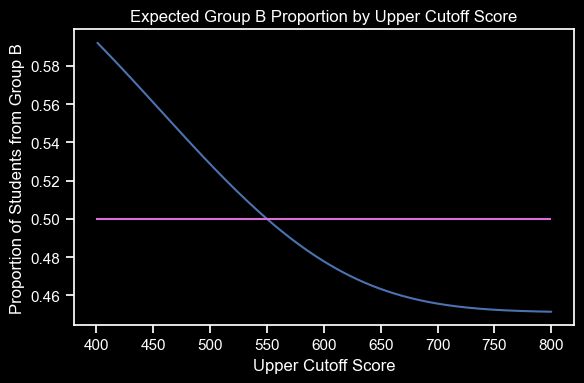

# Problem 3

*Central Limit Theorem Simulations*

Demonstrate that the Central Limit Theorem works on a **Poisson distributed random variable with $\lambda=2.5$**. Use this as the population distribution for all sub-parts.

In [16]:
# You may want a function that does something like this.
# You may even be able to find one that I've provided.
# Make sure you understand how to update it to another distribution.

# I did not provide a specific function for this, but you can use the 
# DistributionAnalyzer class to generate samples and perform statistical 
# analysis on different distributions as shown in the previous sections.

## 3A

Simulate taking the mean of 2 observations of the variable 1000 times. Make a histogram and boxplot of the means. Comment on the 'normality' of the sampling distribution. Does this distribution appear normal? If no, why not? 

Plots for n=2:


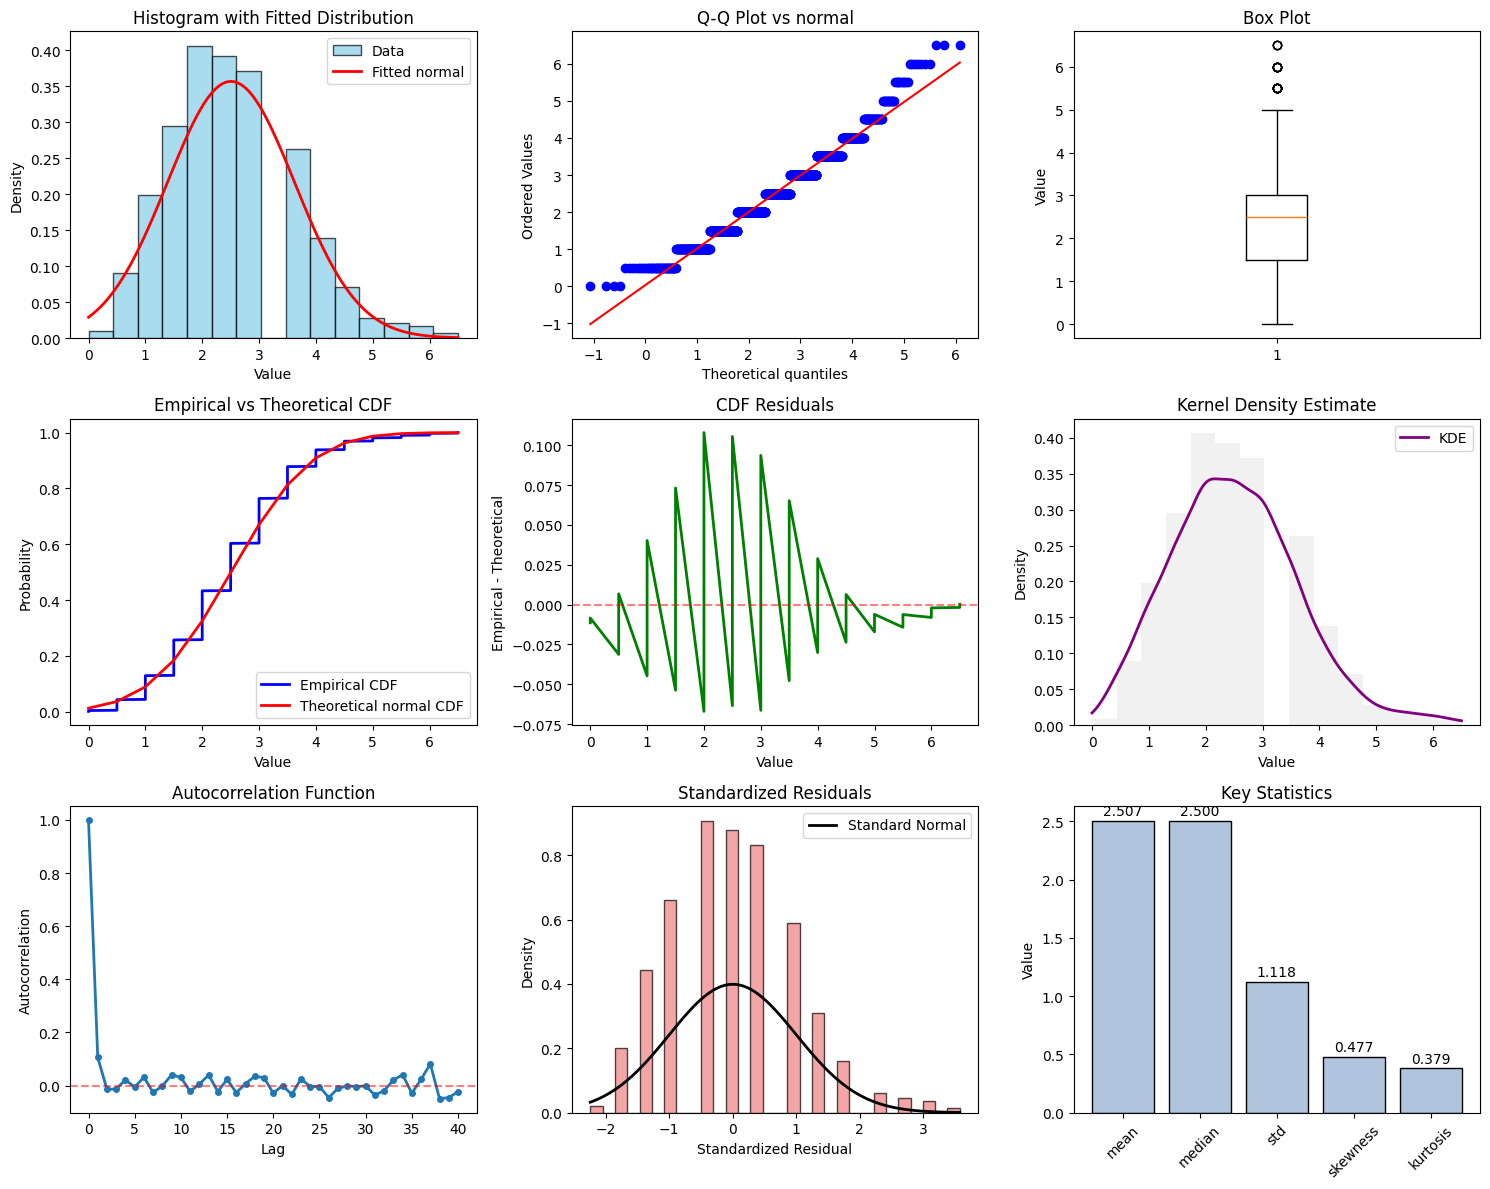

In [18]:
# Simulation parameters
n_simulations = 1000
n_obs_a = 2
lambda_param = 2.5

# Run the simulation for n=2
sample_means_a = []
for _ in range(n_simulations):
    # Generate 2 observations from a Poisson distribution
    observations = analyzer.generate_samples('poisson', size=n_obs_a, mu=lambda_param)
    # Calculate the mean and store it
    sample_means_a.append(np.mean(observations))

# Convert to a numpy array for help with the analysis (can be easier to work with than other data types)
sample_means_a = np.array(sample_means_a)

# Create those plots
print("Plots for n=2:")
analyzer.plot_distribution(sample_means_a, distribution='normal', bins=15)

🟢 *Comment on the normality of this sampling distribution.*

The histogram with the fitted normal overlay shows that the data could be normal, but it does show some deviations from the overlay. The Q-Q plot shows a similar trend where the data should follow the red line, if it is normal. It does follow the red line best at the central part of the plot, but deviates along with the tails. This suggests that the tails have more extreme values than a normal distribution. The box plot helps to support this by showing multiple outliers on the high-end. The remaining plots largely reiterate these ideas.

From this analysis, the data is somewhat normal, but it does exhibit a positive skew (skewed to the right) with heavier tails than a normal distribution.

🔴

#### Hint

Look at the CLT lesson notebook. There's a function there that you can easily modify to use another distribution.

## 3B

Simulate taking the mean of 10 observations of the variable 1000 times. Make a histogram and boxplot of the means. Comment on the 'normality' of the sampling distribution.

Plots for n=10:


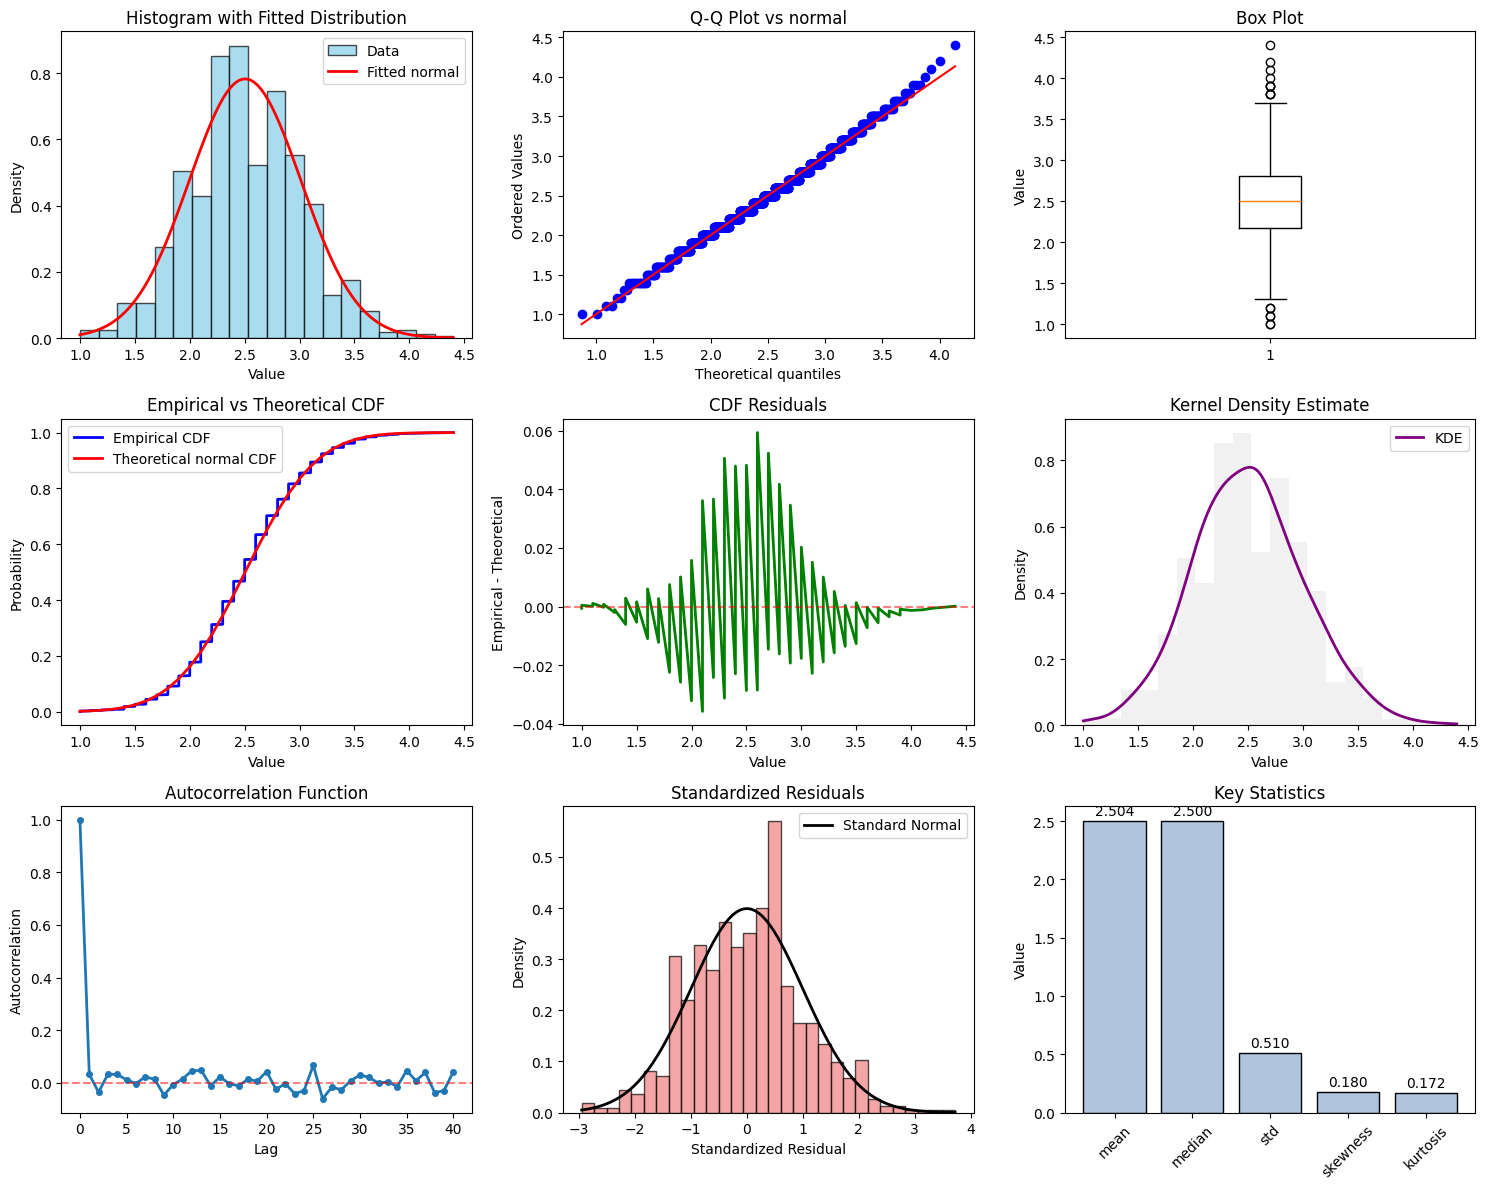

In [19]:
# Create those plots
# Simulation parameters
n_obs_b = 10

# Run the simulation for n=10
sample_means_b = []
for _ in range(n_simulations):
    observations = analyzer.generate_samples('poisson', size=n_obs_b, mu=lambda_param)
    sample_means_b.append(np.mean(observations))

sample_means_b = np.array(sample_means_b)

# Create plots
print("Plots for n=10:")
analyzer.plot_distribution(sample_means_b, distribution='normal', bins=20)

🟢 *Comment on the normality of this sampling distribution.*

The histogram with the fitted normal overlay shows that the data is largely follows the overlay, with some very minor deviations along the tails of the data (less so than the plots in part a). The Q-Q plot shows a similar trend where the data almost perfectly follows the red line. There is some very minor deviations along with the tails. This suggests that the tails have more extreme values than a normal distribution. The box plot helps to support this by showing multiple outliers on the high-end. The remaining plots largely reiterate these ideas.

Compared to the results generated in part a, these plots support that this distribution is close to a normal distribution. This helps to demonstrate the effect of the Central Limit Theorem because the sample size increased, the distribution of the sample means becomes more normal.

## 3C
**Generative AI is not allowed for use in answering this question.**

How large does $n$ (the number of observations used to calculate the mean) need to be for the sampling distribution to seem to *approximate* normality? Justify your answer. Use logic to argue your point augmented by math and graphics as needed.

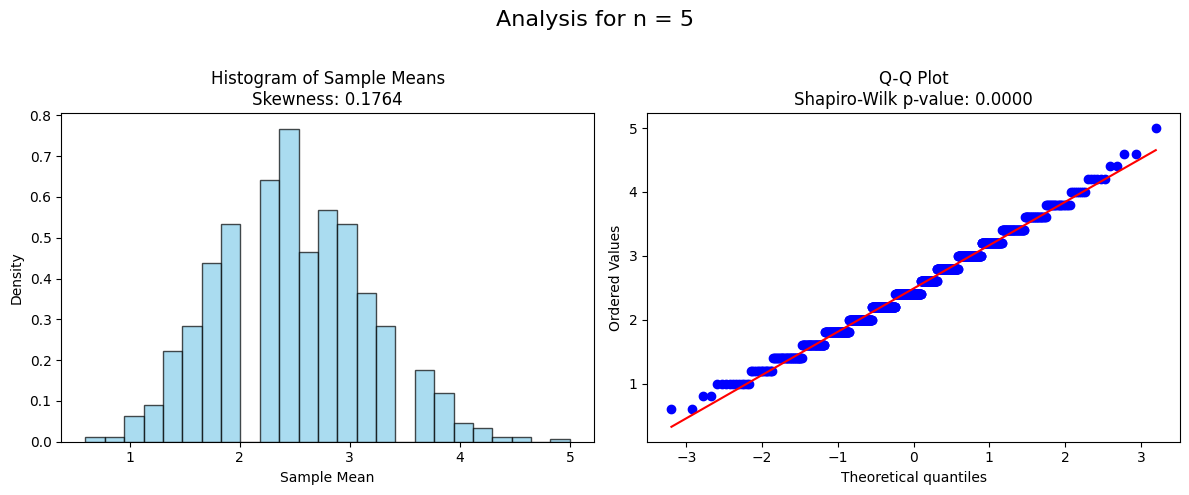

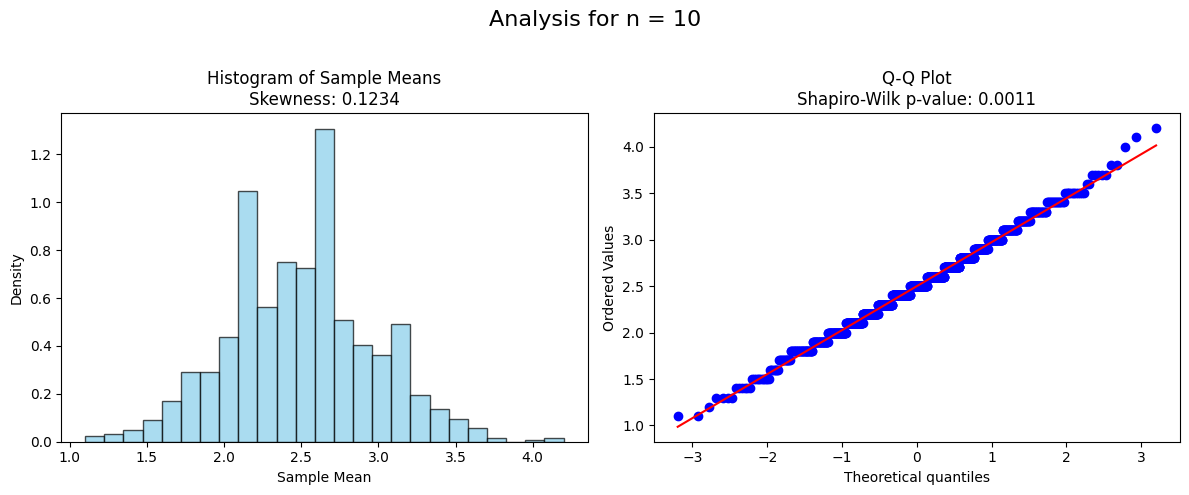

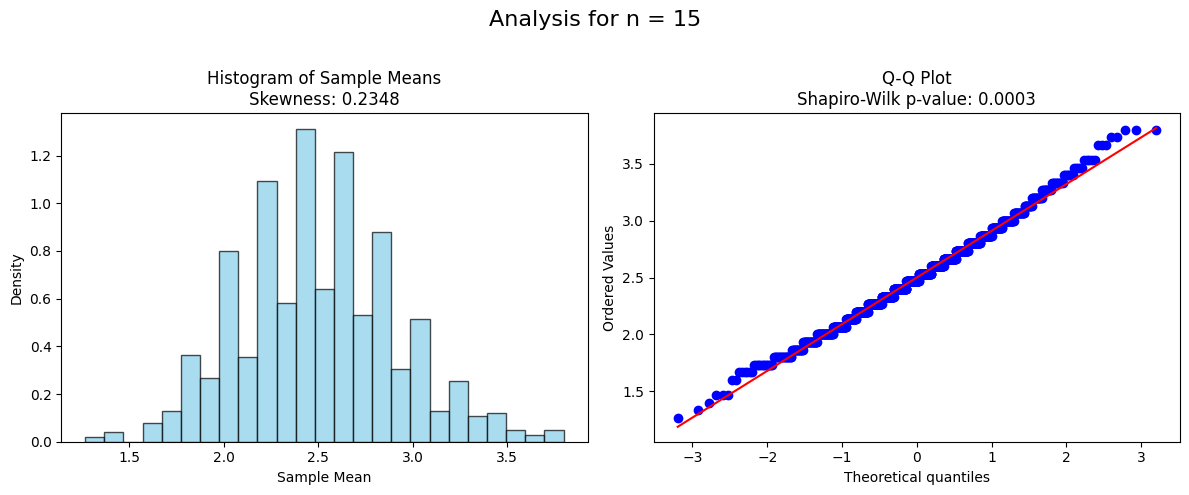

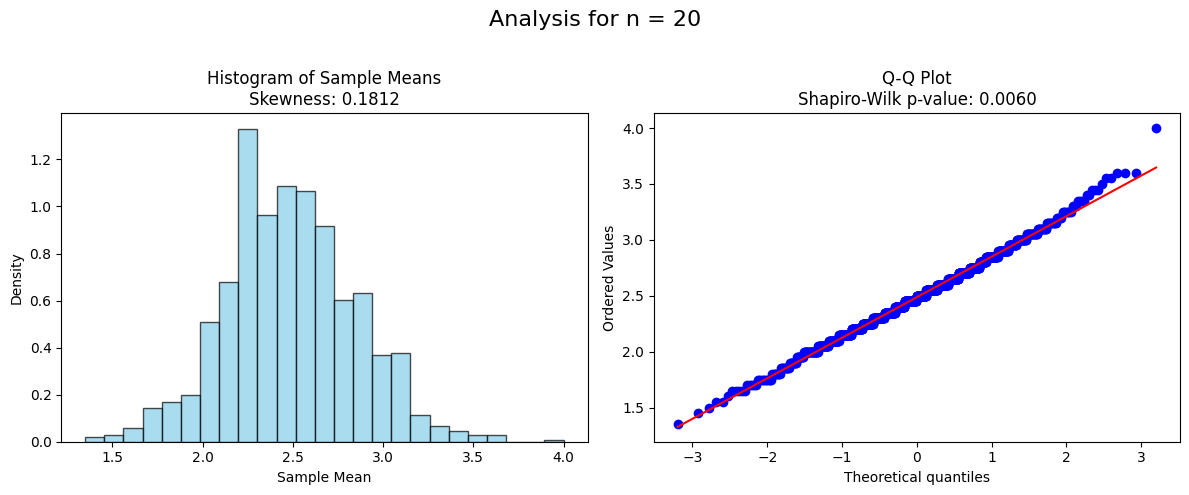

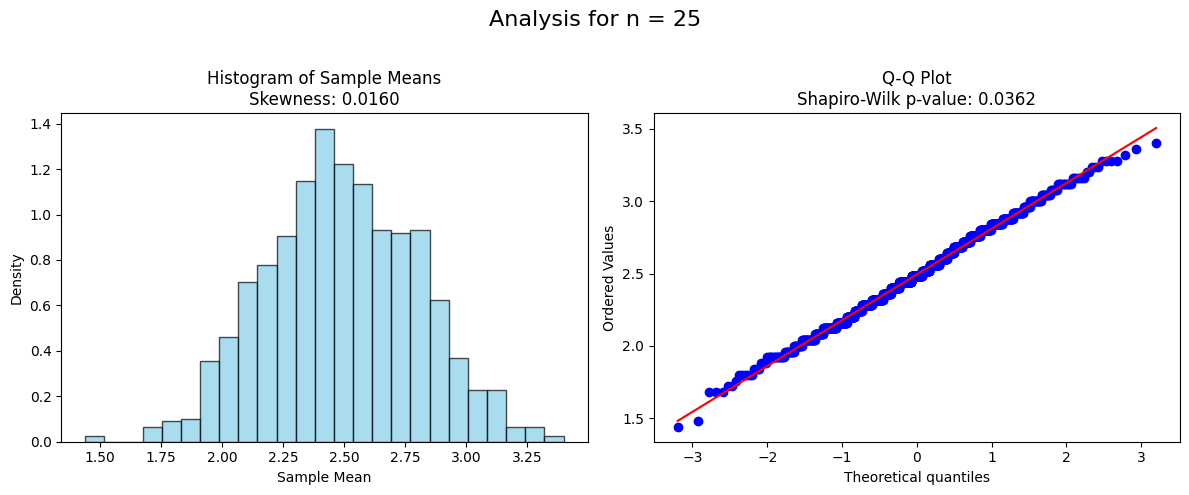

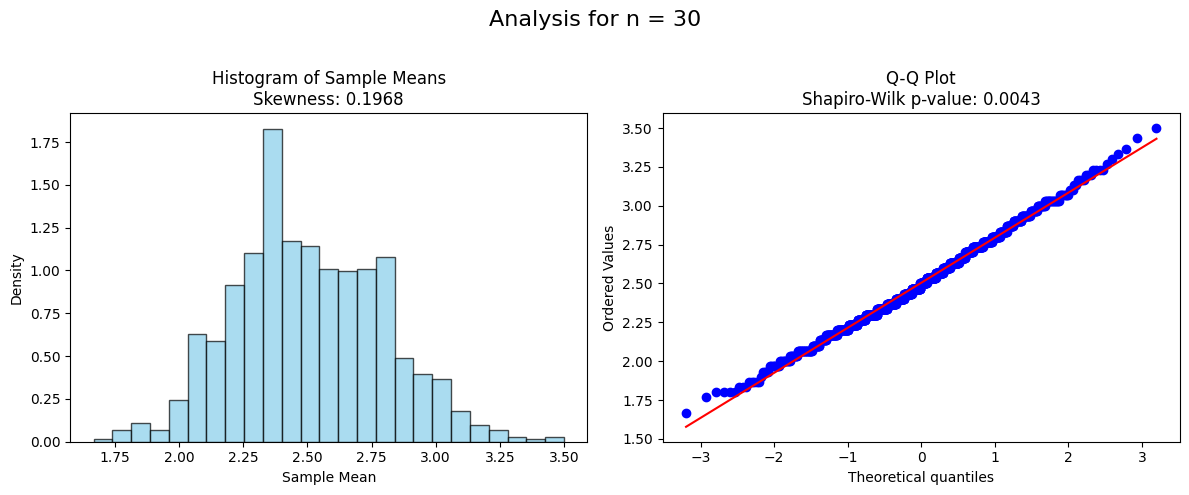

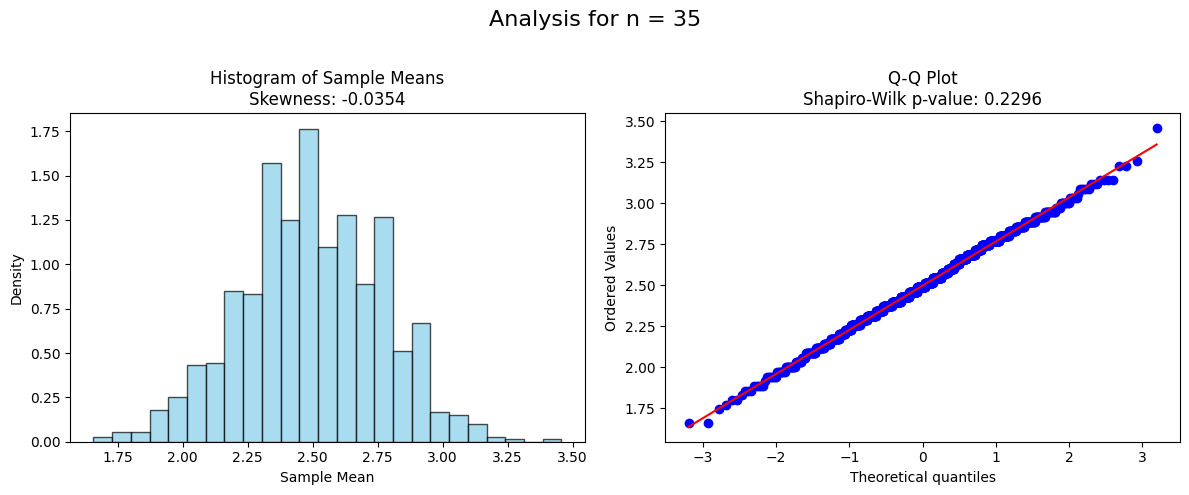

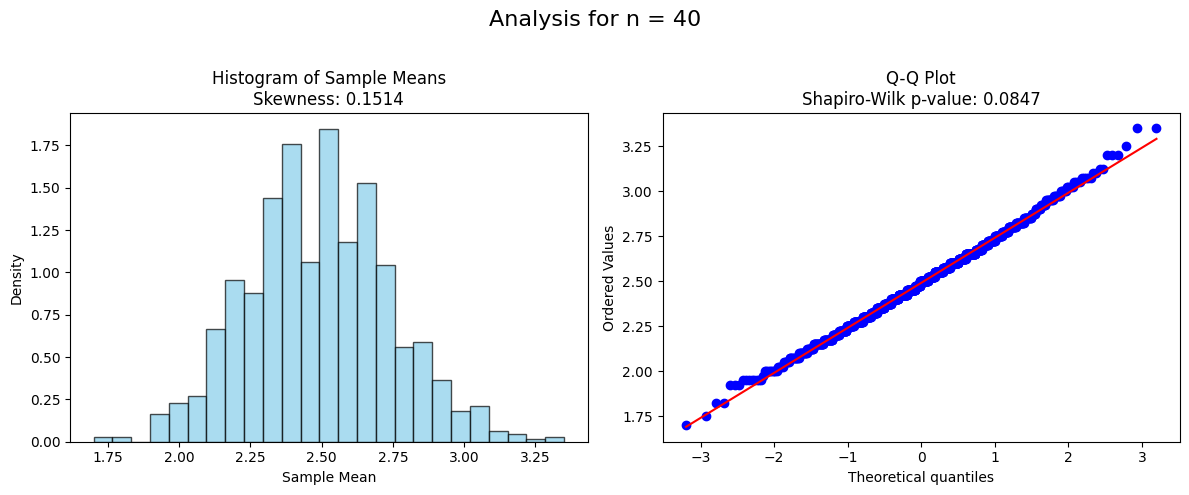

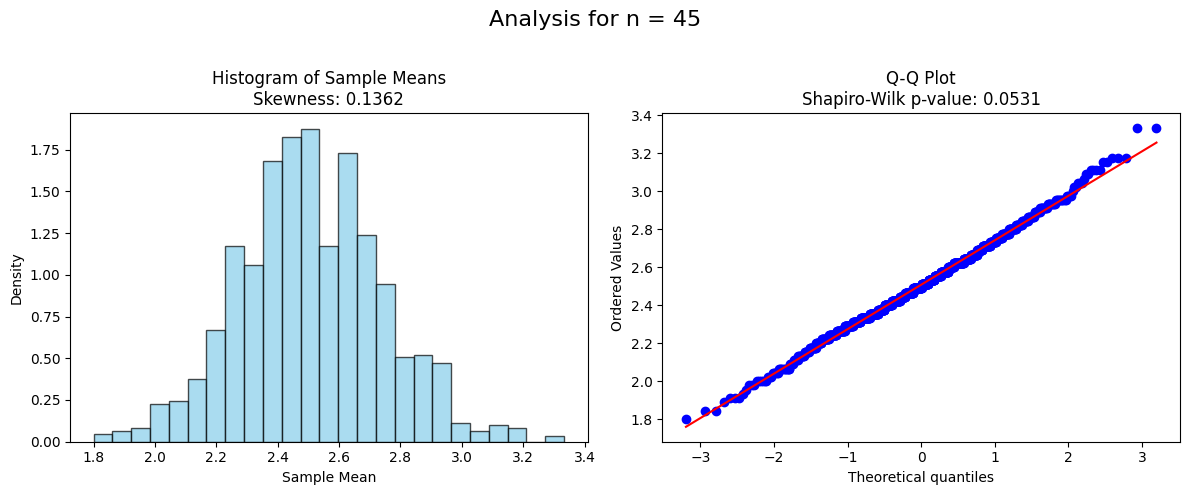

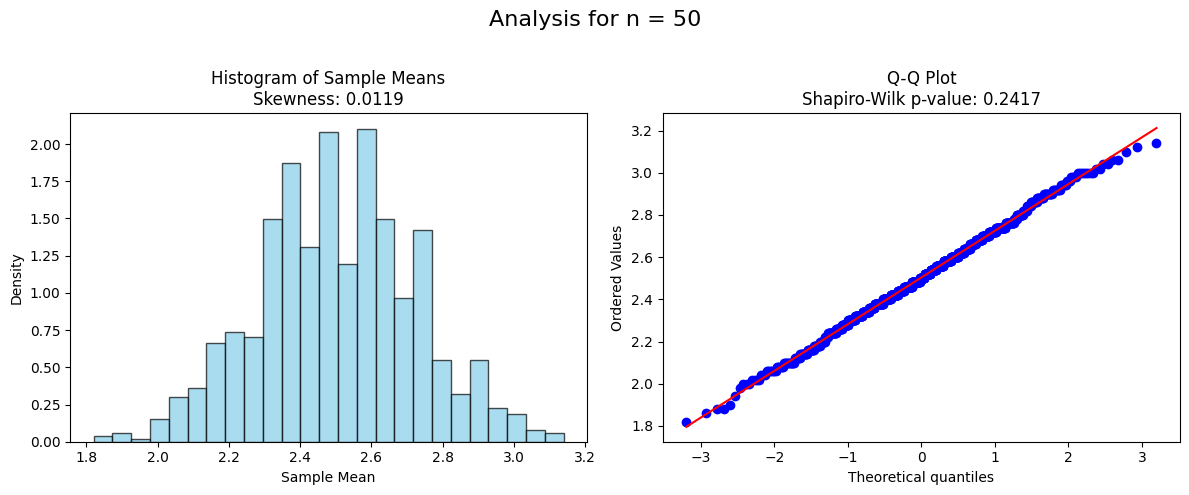

--- Summary of Normality Analysis ---
Sample Size (n)      Skewness        Kurtosis        Shapiro-Wilk p-value     
------------------------------------------------------------
5                    0.1764          -0.0984         0.0000                    (Normal at alpha=0.05? No)
10                   0.1234          0.0973          0.0011                    (Normal at alpha=0.05? No)
15                   0.2348          0.0916          0.0003                    (Normal at alpha=0.05? No)
20                   0.1812          0.3283          0.0060                    (Normal at alpha=0.05? No)
25                   0.0160          -0.2375         0.0362                    (Normal at alpha=0.05? No)
30                   0.1968          -0.1201         0.0043                    (Normal at alpha=0.05? No)
35                   -0.0354         -0.0733         0.2296                    (Normal at alpha=0.05? Yes)
40                   0.1514          0.0708          0.0847                    

In [ ]:
# Parameters
n_simulations = 1000
lambda_param = 2.5
sample_sizes_to_test = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
results = []

# Loop through different sample sizes
for n in sample_sizes_to_test:
    # Run the simulation for the current n
    sample_means = []
    for _ in range(n_simulations):
        observations = analyzer.generate_samples('poisson', size=n, mu=lambda_param)
        sample_means.append(np.mean(observations))
    sample_means = np.array(sample_means)

    # Calculate Statistics
    stats = analyzer.calculate_statistics(sample_means)
    skewness = stats['skewness']
    kurtosis = stats['kurtosis']

    # Perform Normality Test
    # Chose shapiro-wilk test for normality because it is suitable for sample sizes less than 50
    # and provides a good balanace between power and robustness.
    normality_test = analyzer.hypothesis_test(sample_means, test_type='normality')
    p_value = normality_test['shapiro_wilk']['p_value']

    # Store results
    results.append({
        'n': n,
        'skewness': skewness,
        'kurtosis': kurtosis,
        'p_value': p_value
    })

    # Visualization
    # Create a focused plot (Histogram and Q-Q Plot)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Analysis for n = {n}', fontsize=16)

    # Histogram
    axes[0].hist(sample_means, bins=25, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0].set_title(f'Histogram of Sample Means\nSkewness: {skewness:.4f}')
    axes[0].set_xlabel('Sample Mean')
    axes[0].set_ylabel('Density')

    # Q-Q Plot
    from scipy import stats as scipy_stats
    scipy_stats.probplot(sample_means, dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot\nShapiro-Wilk p-value: {p_value:.4f}')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Print a summary table
print("--- Summary of Normality Analysis ---")
print(f"{'Sample Size (n)':<20} {'Skewness':<15} {'Kurtosis':<15} {'Shapiro-Wilk p-value':<25}")
print("-" * 60)
for res in results:
    is_normal_at_05 = 'Yes' if res['p_value'] > 0.05 else 'No'
    print(f"{res['n']:<20} {res['skewness']:<15.4f} {res['kurtosis']:<15.4f} {res['p_value']:<25.4f} (Normal at alpha=0.05? {is_normal_at_05})")

🟢 *Give an assessment (this is a judgment call rooted in critical thinking and some graphical evidence). Make sure you justify your answer.*

To help determine how many samples are required, I iterated through several different sample sizes starting at 5 to 50 in increments of 5. I simulated generating these number of samples, calculated their skewness, and completed a Shapiro-Wilk normality test to evaluate if the generated samples appeared to be normal (with 95% confidence). The Shapiro-Wilk normality test is one of the more reliable tests when the sample size is smaller. I thought this was ideal for this example as the goal was to determine the least amount of samples where a Poisson distribution with $\lambda=2.5$ can approximate normality. Skewness is also another key factor I considered here as it helps to describe the data a little bit deeper (than just the normality test) where a larger skewness indicates the data is asymmetric, and a value of 0 means the data is perfectly symmetric. Kurtosis is another important metric when trying to identify normality where it helps to characterize the tailedness of the data. High positive kurtosis indicates heavier tails, suggesting more outliers, while negative kurtosis indicates thinner tails and fewer outliers.

The results showed a pretty consistent trend where around 30-40 samples (possibly as low as 25) the skewness of the data is noticeably lower, and the resulting p-value from the normality test jumps up. I ran the code above a couple of times to see if there was much deviation, and the results did deviate somewhat. In general, the results did demonstrate a drop in skewness, as well as kurtosis, and the calculated p-value for the Shapiro-Wilk normality test, in general, indicated a normal distribution (p-value>0.05). Looking at the plots, the histograms at 30+ samples appear to resemble a normal distribution with their Q-Q plots all closely following the red lines.